In [96]:
import torch
import numpy as np
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchmetrics import ConfusionMatrix
from timeit import default_timer as timer
from tqdm.auto import tqdm
from mlxtend.plotting import plot_confusion_matrix
from torchvision import transforms

In [97]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [98]:
LR = 0.001

In [99]:
df = pd.read_csv("../../datasets/icml_face_data.csv")

In [100]:
emotion_counts = df['emotion'].value_counts().sort_index()


In [101]:
emotion_classes = {
    0: "Angry", 
    1: "Disgust", 
    2: "Fear",
    3: "Happy", 
    4: "Sad",     
    5: "Surprise",
    6: "Neutral"
}

In [102]:
class_names = [emotion_classes[i] for i in emotion_counts.index]

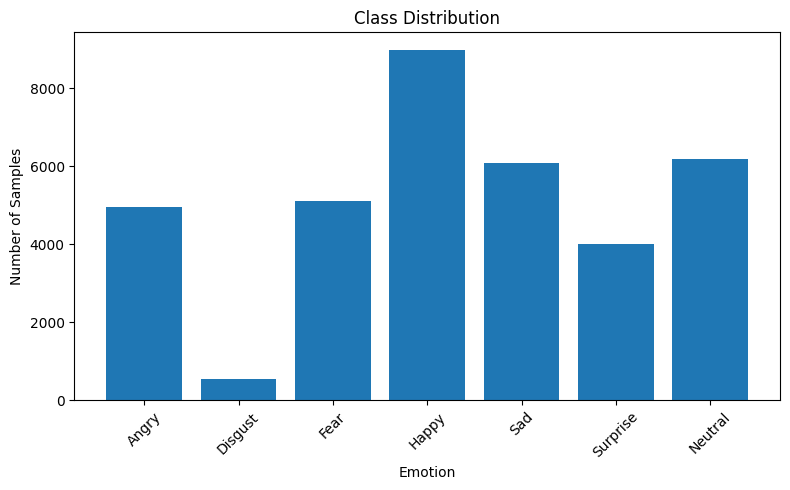

In [103]:
plt.figure(figsize=(8,5))
plt.bar(class_names, emotion_counts.values)
plt.title("Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['emotion'], random_state=42
)

In [105]:
class CSVDataset(Dataset):
    def __init__(self, df, transform=None):
        self.data = df
        self.transform = transform # Store the transform pipeline
        
        # We parse the pixels but keep them in a format that can be transformed
        self.x = np.stack(
            self.data.iloc[:, -1].apply(
                lambda x: np.fromstring(x, sep=' ', dtype=np.float32)
            )
        )
        # Reshape to (N, 48, 48) for now
        self.x = self.x.reshape(-1, 48, 48)
        self.y = self.data.iloc[:, 0].values.astype(np.int64)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.x[idx]
        label = self.y[idx]

        # Convert numpy array to PIL Image or Tensor for torchvision transforms
        # Most augmentations expect a PIL image or a specific Tensor shape
        image = torch.tensor(image).unsqueeze(0) # Shape: (1, 48, 48)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [106]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),                
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),                  
    transforms.Normalize((0.5,), (0.5,)) 
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [107]:
train_data = CSVDataset(train_df, transform=train_transform)
test_data = CSVDataset(test_df, transform=test_transform)

In [108]:
len(train_data), len(test_data)

(28709, 7178)

In [109]:
# see the first training example
image, label = train_data[0]

print(f"image:\n {image}")
print(f"label: {label}")

image:
 tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])
label: 0


Image shape: torch.Size([1, 48, 48]) -> [color_channels, height, width]
Image label: Angry 


Text(0.5, 1.0, 'Angry')

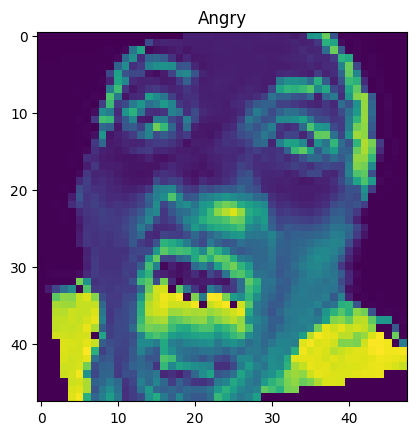

In [110]:
# check the shape of our image
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]} ")
plt.imshow(image.squeeze())
plt.title(class_names[label])

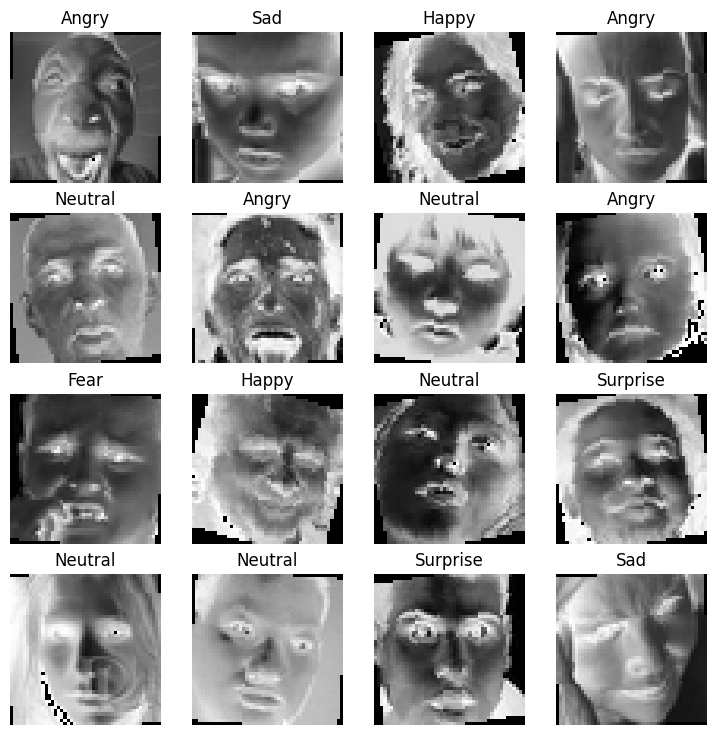

In [111]:
# plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

In [112]:
BATCH_SIZE = 64

# turn datasets into iterables (batches)
# length of DataLoader = Total Samples / batch_size
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True)

In [113]:
# let's check out what we have created
print(f"DataLoader: {train_dataloader, test_dataloader}")
print(f"Lenght of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Lenght of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x0000025B0A851DB0>, <torch.utils.data.dataloader.DataLoader object at 0x0000025A9F871C60>)
Lenght of train_dataloader: 449 batches of 64...
Lenght of test_dataloader: 113 batches of 64...


In [114]:
# Helper Functions
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
    # Returns a dictionary containing the results of model prediction on data_loader.
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            # make prediction
            y_pred = model(X)

            # accumulate the loss and accuracy values per batch
            loss = loss + loss_fn(y_pred, y)
            acc = acc + accuracy_fn(y_true=y, y_pred = y_pred.argmax(dim=1))

        # scale loss and accuracy to find the average loss/acc per batch
        loss = loss / len(data_loader)
        acc = acc / len(data_loader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}


In [115]:
# helper function
def print_train_time(start: float, end: float, device: torch.device = None):
    # Prints difference between start and end time
    total_time  = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    
    return  total_time

In [116]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

# Build Models

In [117]:
class EmotionFERModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        h = hidden_units

        # Block 1 (48 → 24)
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(input_shape, h, kernel_size=3, padding=1),
            nn.BatchNorm2d(h),
            nn.ReLU(),

            nn.Conv2d(h, h, kernel_size=3, padding=1),
            nn.BatchNorm2d(h),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Block 2 (24 → 12)
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(h, h * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(),

            nn.Conv2d(h * 2, h * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Block 3 (12 → 6)
        self.conv_block_3 = nn.Sequential(
            nn.Conv2d(h * 2, h * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(),

            nn.Conv2d(h * 4, h * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Block 4
        self.conv_block_4 = nn.Sequential(
            nn.Conv2d(h * 4, h * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 8),
            nn.ReLU(),
            nn.Dropout2d(0.2),

            nn.Conv2d(h * 8, h * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 8),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        # Block 5 (Spatial size: 3x3 -> 1x1)
        self.conv_block_5 = nn.Sequential(
            nn.Conv2d(h * 8, h * 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(h * 16),
            nn.ReLU(),
            nn.MaxPool2d(2) 
        )
        
        new_fc_size = 512

        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # better for small images
            nn.Flatten(),
            
            nn.Linear(h * 16, new_fc_size),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(new_fc_size, output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.conv_block_3(x)
        x = self.conv_block_4(x)
        x = self.conv_block_5(x)
        x = self.classifier(x)
        return x

In [118]:
image.shape

torch.Size([1, 48, 48])

In [119]:
torch.manual_seed(42)
EmotionRegModel_1 = EmotionFERModel(input_shape=1, hidden_units=32, output_shape=len(class_names)).to(device)
print(EmotionRegModel_1)

EmotionFERModel(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential

In [120]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=EmotionRegModel_1.parameters(), lr=LR)

# functionizing training and testing loops

In [121]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train() 

    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [122]:
torch.manual_seed(42)

# Measure time 
train_time_start_on_cpu = timer()

# set epochs
epochs = 30

# create a optimization and evaluation loop using train_step() and test_step()
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n--------")

    train_step(model=EmotionRegModel_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
    test_step(model=EmotionRegModel_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
    
train_time_end_on_cpu = timer()

total_train_time_model_1 = print_train_time(start=train_time_start_on_cpu, end=train_time_end_on_cpu, device=device)


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 0
--------
Train loss: 1.68780 | Train accuracy: 31.42%


  3%|▎         | 1/30 [00:18<08:43, 18.05s/it]

Test loss: 1.42066 | Test accuracy: 44.65%

Epoch: 1
--------
Train loss: 1.37711 | Train accuracy: 47.02%


  7%|▋         | 2/30 [00:35<08:14, 17.67s/it]

...

Test loss: 1.05279 | Test accuracy: 66.15%

Epoch: 28
--------
Train loss: 0.63165 | Train accuracy: 76.33%


 97%|█████████▋| 29/30 [08:17<00:17, 17.24s/it]

Test loss: 1.08618 | Test accuracy: 65.36%

Epoch: 29
--------
Train loss: 0.61672 | Train accuracy: 76.77%


100%|██████████| 30/30 [08:33<00:00, 17.13s/it]

Test loss: 1.05439 | Test accuracy: 65.69%

Train time on cuda: 513.964 seconds


In [123]:
# get model_1 results
model_1_results = eval_model(
    model=EmotionRegModel_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)
model_1_results

{'model_name': 'EmotionFERModel',
 'model_loss': 1.0599873065948486,
 'model_acc': 65.46460176991151}

# evaluiation

In [124]:
# 1. make predictions with trained model
y_preds = []

EmotionRegModel_1.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        # Send to device
        X = X.to(device)
        
        # 1. Forward pass (output shape: [batch_size, num_classes])
        y_logits = EmotionRegModel_1(X)
        
        # 2. Get the predicted class index 
        # We use dim=1 because that's where the 7 emotion scores are
        y_pred = torch.argmax(y_logits, dim=1)
        
        # 3. Store on CPU
        y_preds.append(y_pred.cpu())
    
# Concatenate list of tensors into one long tensor
y_pred_tensor = torch.cat(y_preds)


Making predictions...: 100%|██████████| 113/113 [00:02<00:00, 45.36it/s]


In [125]:
print(len(y_pred_tensor))
print(y_pred_tensor[:10].dtype)
print(test_data.y.dtype)

7178
torch.int64
int64


'\n\nDiagonal values (dark blue) = correct predictions ✅\nOff-diagonal values = mistakes ❌\n\n'

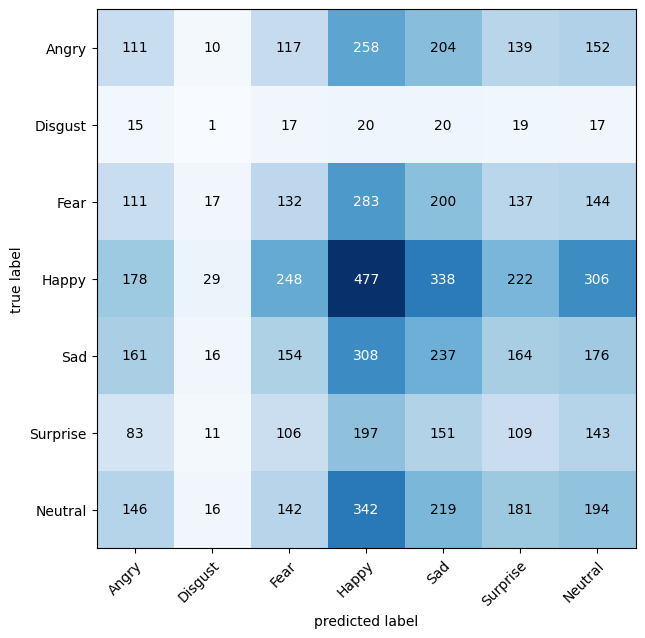

In [126]:
# 2. Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor, 
                         target=torch.as_tensor(test_data.y, dtype=torch.long))

# 3 plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),    # matplotlib likes working with numpy
    class_names=class_names,
    figsize=(10, 7)
)

"""

Diagonal values (dark blue) = correct predictions ✅
Off-diagonal values = mistakes ❌

"""